# Synthetic Dataset


Import libraries


In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from custom_lstm.utils import ew_acf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from hurst import compute_Hc

In [2]:
OUTPUT_FILE = "../../data/preprocessed/synthetic_dataset_arfima.csv"

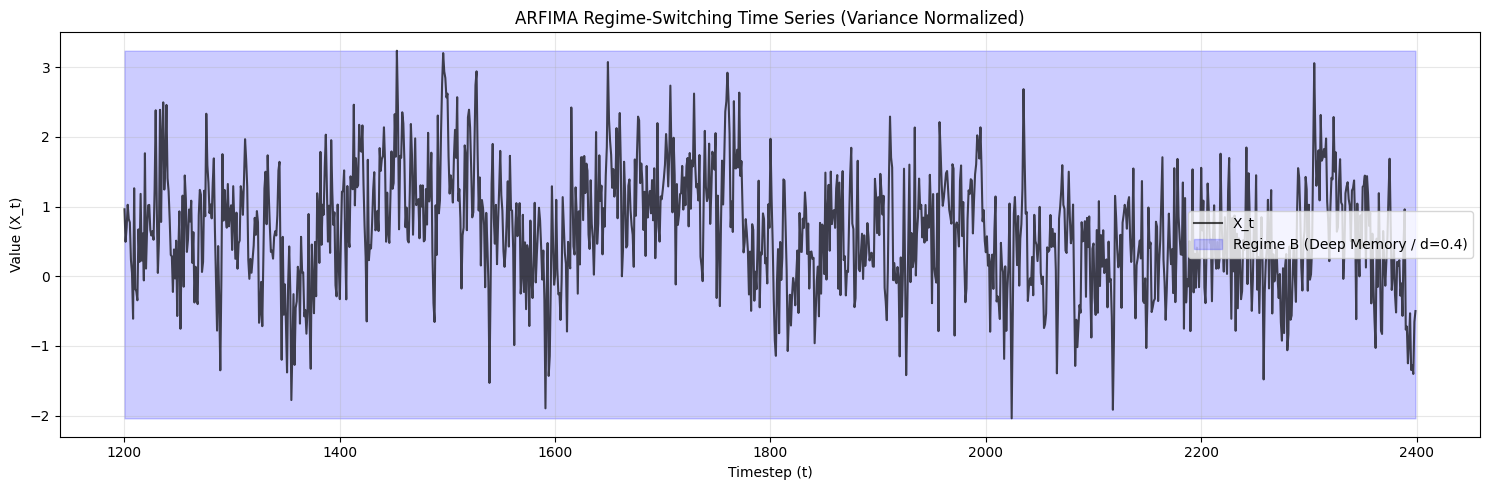

In [5]:
from scipy.signal import fftconvolve
from scipy.special import gamma


def generate_regime_switching_arfima(
    total_steps: int = 10000, regime_duration: int = 1000, d_memory: float = 0.4, target_std: float = 1.0, seed: int = 42
) -> pd.DataFrame:
    """
    Generates a variance-normalized sequence alternating between pure white noise
    and ARFIMA(0, d, 0) true long-term memory.
    """
    np.random.seed(seed)

    if not (0.0 < d_memory < 0.5):
        raise ValueError("Parameter d_memory must be in (0.0, 0.5) for stationarity.")

    # 1. Generate the continuous base white noise sequence
    epsilon = np.random.normal(0, target_std, total_steps)

    # 2. Calculate fractional integration weights for the memory regime
    weights = np.zeros(total_steps)
    weights[0] = 1.0
    for k in range(1, total_steps):
        weights[k] = weights[k - 1] * (k - 1 + d_memory) / k

    # 3. Calculate the theoretical variance multiplier of ARFIMA(0, d, 0)
    # This proves the exact analytical variance inflation caused by the long memory.
    gamma_num = gamma(1 - 2 * d_memory)
    gamma_den = gamma(1 - d_memory) ** 2
    variance_inflation = gamma_num / gamma_den

    # Scale factor required to force the ARFIMA regime to match the noise regime
    scale_factor = 1.0 / np.sqrt(variance_inflation)

    # 4. Generate the full ARFIMA sequence and normalize it mathematically
    X_memory_raw = fftconvolve(epsilon, weights, mode="full")[:total_steps]
    X_memory = X_memory_raw * scale_factor

    # 5. Determine regimes and splice
    # 1 indicates the deep memory regime (ARFIMA), 0 indicates the noise regime
    regime_wave = (np.arange(total_steps) // regime_duration) % 2
    is_redundant = regime_wave

    # Route the sequence: if memory regime, output X_memory; else, output epsilon
    X = np.where(is_redundant == 1, X_memory, epsilon)

    df = pd.DataFrame({"value": X, "is_redundant": is_redundant})

    return df


# ==========================================
# Execution & Mathematical Verification
# ==========================================
if __name__ == "__main__":
    d_val = 0.4
    synthetic_data = generate_regime_switching_arfima(total_steps=12000, regime_duration=1200, d_memory=d_val)[1200:2400]

    # # Extract single blocks for independent Hurst verification
    # noise_block = synthetic_data["value"][0:1200]
    # memory_block = synthetic_data["value"][1200:2400]

    # # Compute Hurst on isolated regimes
    # H_noise, _, _ = compute_Hc(noise_block, kind="change", simplified=True)
    # H_memory, _, _ = compute_Hc(memory_block, kind="change", simplified=True)

    # print("-" * 40)
    # print(f"Computed Hurst (Noise Regime):  {H_noise:.4f} (Expected ~0.50)")
    # print(f"Computed Hurst (Memory Regime): {H_memory:.4f} (Expected ~{d_val + 0.5:.2f})")
    # print("-" * 40)

    # Visual Verification
    plt.figure(figsize=(15, 5))
    plt.plot(synthetic_data["value"], label="X_t", color="black", alpha=0.7)

    plt.fill_between(
        synthetic_data.index,
        synthetic_data["value"].min(),
        synthetic_data["value"].max(),
        where=(synthetic_data["is_redundant"] == 1),
        color="blue",
        alpha=0.2,
        label=f"Regime B (Deep Memory / d={d_val})",
    )
    plt.title("ARFIMA Regime-Switching Time Series (Variance Normalized)")
    plt.xlabel("Timestep (t)")
    plt.ylabel("Value (X_t)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [8]:
time_series = synthetic_data["value"]
time_series.to_csv(OUTPUT_FILE, index=False)
time_series = time_series.to_numpy()

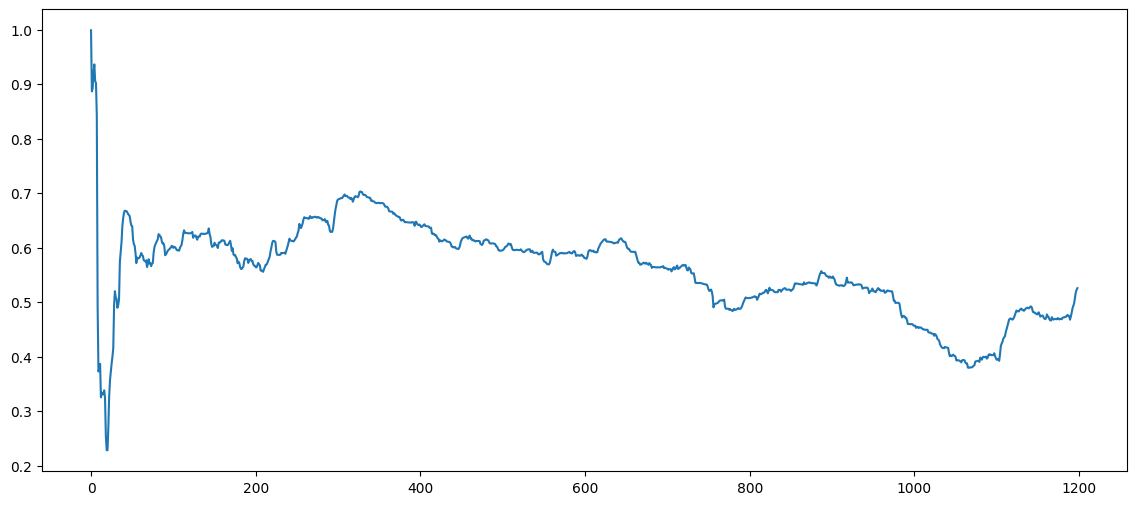

In [9]:
autocorr = ew_acf(time_series, lag=1, lambda_=0.996)
plt.figure(figsize=(14, 6))
plt.plot(autocorr)

### ACF

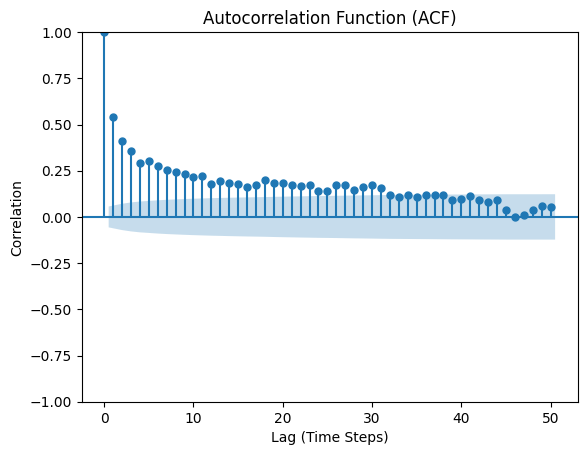

In [11]:
plot_acf(time_series, lags=50, alpha=0.05)
plt.title("Autocorrelation Function (ACF)")
plt.xlabel("Lag (Time Steps)")
plt.ylabel("Correlation")
plt.show()

### PACF

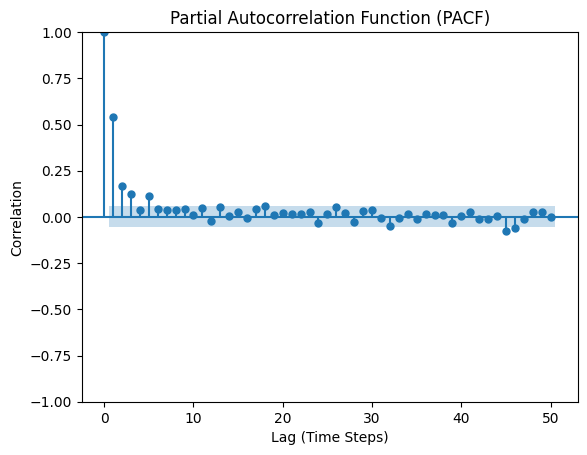

In [13]:
plot_pacf(time_series, lags=50)
plt.title("Partial Autocorrelation Function (PACF)")
plt.xlabel("Lag (Time Steps)")
plt.ylabel("Correlation")
plt.show()

## Hurst Exponent


Hurst Exponent (H): 0.9592


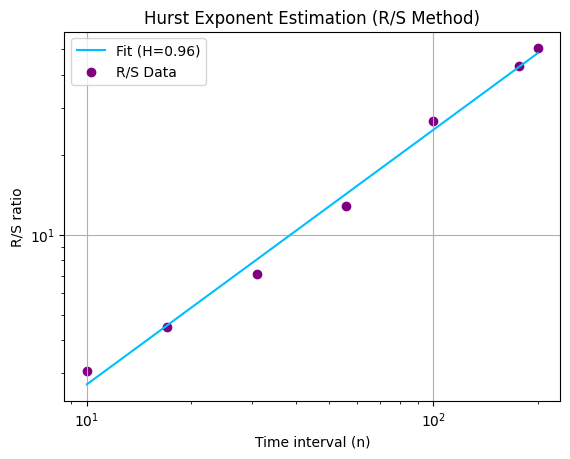

In [14]:
H, c, data = compute_Hc(time_series[1000:2000], kind="change", simplified=False)

print(f"Hurst Exponent (H): {H:.4f}")
f, ax = plt.subplots()
ax.plot(data[0], c * data[0] ** H, color="deepskyblue", label=f"Fit (H={H:.2f})")
ax.scatter(data[0], data[1], color="purple", label="R/S Data")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Time interval (n)")
ax.set_ylabel("R/S ratio")
ax.legend()
plt.title("Hurst Exponent Estimation (R/S Method)")
plt.grid(True)
plt.show()